
| <h1> **Midterm Quiz 2** </h1> | <h1> **Data Analysis using Pandas** </h1> |
|--- | --- |
Name: | Rubang, Jethro Aaron S.<br>
Course and Section: |  CPE 311-CPE22S3<br>
Instructor: | Eng. Neal Barton James Matira
Date Performed: | March 5, 2026
Date Submitted: | March 5, 2026


<hr>


# Extracting the Dataset from kaggle

In [18]:
# Using kagglehub to download dataset
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")
print("Path to dataset files:", path)

# Assuming CSV files are in extracted path
dataset_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV Files Found:", dataset_files)

# Load one file as example
df = pd.read_csv(os.path.join(path, dataset_files[0]))
df.head()

Path to dataset files: C:\Users\tipqc\.cache\kagglehub\datasets\supplejade\rt-iot2022real-time-internet-of-things\versions\3
CSV Files Found: ['RT_IOT2022.csv']


,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


# Tranforming the dataset

In [27]:
# Check for missing values
df.isnull().sum()

# Rename columns for clarity
df.rename(columns={'id.orig_p':'src_port', 'id.resp_p':'dest_port', 'Attack_type':'attack_type'}, inplace=True)

# Convert proto and service to lowercase for consistency
df['proto'] = df['proto'].str.lower()
df['service'] = df['service'].str.lower()

# Filter only relevant columns for initial analysis
cols_to_keep = ['no', 'src_port', 'dest_port', 'proto', 'service', 'flow_duration', 
                'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'attack_type']
df_transformed = df[cols_to_keep]

# Remove duplicates 
df_transformed.drop_duplicates(inplace=True)

# Show transformed dataset
df_transformed.head()

C:\Users\tipqc\AppData\Local\Temp\ipykernel_13620\1104561417.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transformed.drop_duplicates(inplace=True)


,no,src_port,dest_port,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,MQTT_Publish


# Load the Transformed dataset

In [33]:
# Count attack types
attack_counts = df_transformed['attack_type'].value_counts()
print(attack_counts)

attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


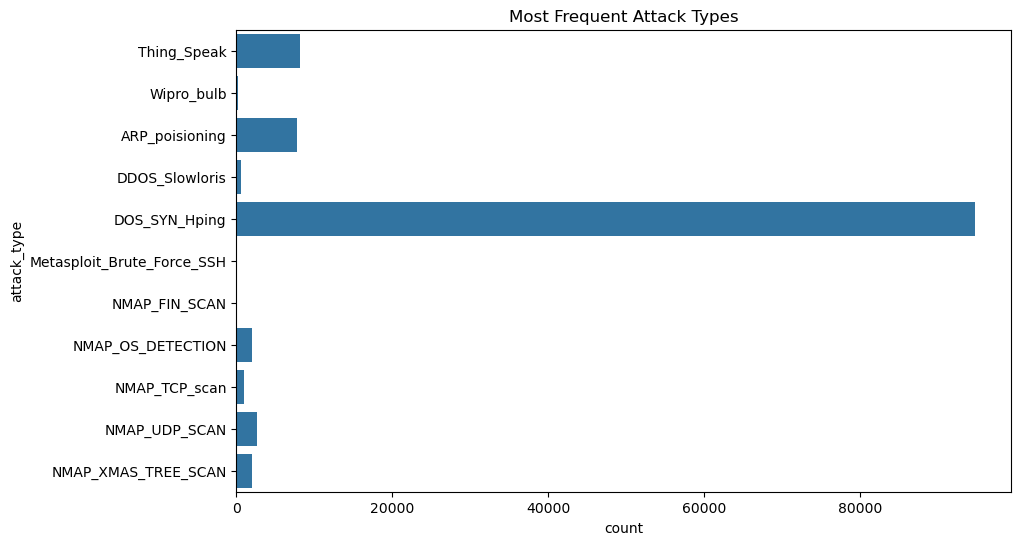

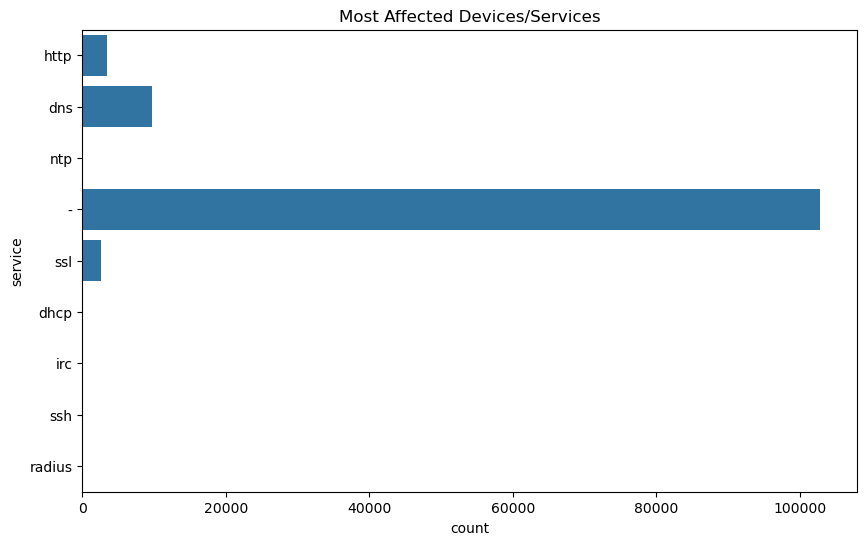

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Attack type distribution
plt.figure(figsize=(10,6))
sns.countplot(y='attack_type', data=df_transformed[df_transformed['attack_type'] != 'MQTT_Publish'])
plt.title('Most Frequent Attack Types')
plt.show()

# Most affected devices/services
plt.figure(figsize=(10,6))
sns.countplot(y='service', data=df_transformed[df_transformed['attack_type'] != 'MQTT_Publish'])
plt.title('Most Affected Devices/Services')
plt.show()

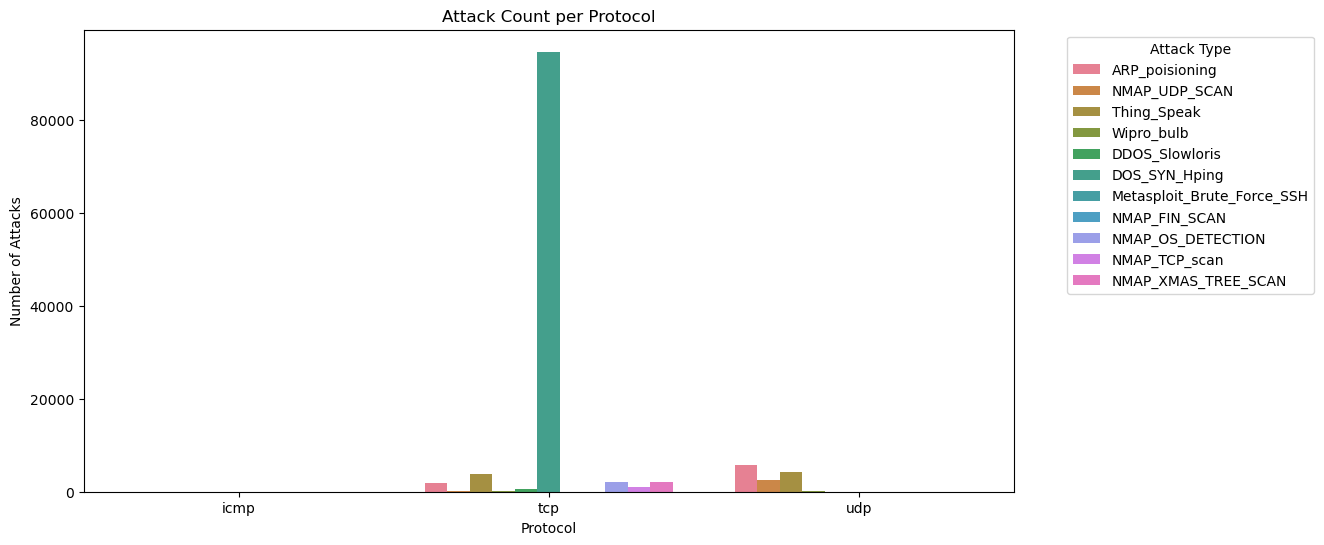

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only attack traffic
attack_df = df_transformed[df_transformed['attack_type'] != 'MQTT_Publish']

# Count of attacks per protocol
protocol_attack = attack_df.groupby(['proto', 'attack_type']).size().reset_index(name='count')

# Create a stacked bar plot
plt.figure(figsize=(12,6))
sns.barplot(x='proto', y='count', hue='attack_type', data=protocol_attack)
plt.title('Attack Count per Protocol')
plt.xlabel('Protocol')
plt.ylabel('Number of Attacks')
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()